# Step 7: GNN Risk Prediction Model (Enhanced Version)

Build a Heterogeneous Graph Neural Network (H-GNN) for predicting disease risk from food ingredients.

**Components:**
1. Data Loading - Load full knowledge graph (USDA + PubMed)
2. Graph Construction - Build DGL heterogeneous graph
3. Feature Engineering - Node embeddings + Edge features (PubMed evidence count)
4. Label Creation - Multi-label disease prediction
5. Model Definition - HeteroGNN with SAGEConv
6. Training Loop - Memory-aware mini-batch training
7. Full-Graph Inference - Batched prediction
8. Evaluation & Saving Outputs - AUC, F1, Precision@K


## 1. Setup and Imports


In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: NVIDIA GeForce GTX 1660 SUPER
GPU Memory: 6.4 GB


In [2]:
# Install DGL if not present (GPU version for CUDA)
try:
    import dgl
    from dgl import nn as dglnn
    from dgl.dataloading import DataLoader, NeighborSampler
    print(f"DGL version: {dgl.__version__}")
except ImportError:
    print("Installing DGL...")
    import subprocess
    subprocess.run(['pip', 'install', 'dgl', '-f', 'https://data.dgl.ai/wheels/cu118/repo.html'])
    import dgl
    from dgl import nn as dglnn
    from dgl.dataloading import DataLoader, NeighborSampler


DGL version: 2.2.1+cu118


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report, precision_score
import time
from tqdm import tqdm
import matplotlib.pyplot as plt


## 2. Configuration (Memory-Aware for GTX 1660 Super 6GB)


In [4]:
# Configuration - Optimized for GTX 1660 Super 6GB VRAM
CONFIG = {
    # Data paths
    'kg_path': '../data/pre-processed/kg/',
    'model_path': '../models/',
    
    # Target diseases for prediction
    'target_diseases': [
        'diabetes',
        'obesity', 
        'hypertension',
        'cancer',
        'cardiovascular disease'
    ],
    
    # Model hyperparameters (optimized for GTX 1660 Super 6GB)
    'embedding_dim': 128,
    'hidden_dim': 128,
    'num_layers': 2,
    'num_heads': 4,
    'dropout': 0.3,
    
    # Training parameters - Memory aware
    'batch_size': 256,  # Reduced from 512 for memory safety
    'num_neighbors': [5, 5],  # 2-hop sampling, 5 neighbors per hop
    'learning_rate': 0.001,
    'num_epochs': 50,
    'patience': 5,  # Early stopping
    
    # Inference parameters
    'inference_batch_size': 50000,  # Nodes per batch for full graph inference
    
    # Precision@K values
    'precision_k_values': [5, 10],
}

# Create model directory
os.makedirs(CONFIG['model_path'], exist_ok=True)
print("Configuration loaded!")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Neighbor sampling: {CONFIG['num_neighbors']} (2-hop)")
print(f"  Embedding dim: {CONFIG['embedding_dim']}")


Configuration loaded!
  Batch size: 256
  Neighbor sampling: [5, 5] (2-hop)
  Embedding dim: 128


## 3. GPU Memory Monitoring Utilities


In [5]:
def get_gpu_memory_usage():
    """Get current GPU memory usage in GB."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        return allocated, reserved
    return 0, 0

def print_gpu_memory(phase=""):
    """Print GPU memory usage."""
    if torch.cuda.is_available():
        allocated, reserved = get_gpu_memory_usage()
        print(f"GPU Memory [{phase}]: Allocated: {allocated:.2f} GB, Reserved: {reserved:.2f} GB")

def clear_gpu_cache():
    """Clear GPU cache to free memory."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
# Initial memory check
print_gpu_memory("Initial")


GPU Memory [Initial]: Allocated: 0.00 GB, Reserved: 0.00 GB


## 4. Data Loading


In [6]:
# Load PubMed knowledge graph triples
print("Loading PubMed knowledge graph triples...")
pubmed_file = os.path.join(CONFIG['kg_path'], 'pubmed_kg_triples.csv')
pubmed_df = pd.read_csv(pubmed_file)
print(f"Loaded {len(pubmed_df)} PubMed triples")
print(f"Columns: {pubmed_df.columns.tolist()}")
pubmed_df.head()


Loading PubMed knowledge graph triples...
Loaded 30567 PubMed triples
Columns: ['subject', 'predicate', 'object', 'pmid', 'title', 'year', 'journal']


,subject,predicate,object,pmid,title,year,journal
0,protein,RELATES_TO,"diabetes, insulin resistance, cardiovascular d...",41390803,Association between triglyceride-glucose index...,2025,Cardiovascular diabetology
1,protein,RELATES_TO,alzheimer,41390778,Multi-task learning identifies shared genetic ...,2025,Scientific reports
2,protein,RELATES_TO,"diabetes, obesity, diabetes mellitus",41390701,Obesity concurrent with gestational diabetes m...,2025,Scientific reports
3,protein,RELATES_TO,"diabetes, type 2 diabetes",41390575,The RNA-binding protein CPEB1 marks healthy ad...,2025,Scientific reports
4,protein,RELATES_TO,"inflammation, cardiovascular disease, stroke, ...",41390442,Genetic insights into 5-LOX-activating protein...,2025,Human genomics


In [7]:
# Load USDA food-ingredient triples (all parts)
print("\nLoading USDA triples...")
usda_dfs = []
usda_files = sorted([f for f in os.listdir(CONFIG['kg_path']) if f.startswith('triples_part_')])

for f in usda_files:
    filepath = os.path.join(CONFIG['kg_path'], f)
    df = pd.read_csv(filepath)
    usda_dfs.append(df)
    print(f"  Loaded {f}: {len(df):,} triples")

usda_df = pd.concat(usda_dfs, ignore_index=True)
print(f"\nTotal USDA triples: {len(usda_df):,}")
print(f"Unique predicates: {usda_df['Predicate'].unique()}")



Loading USDA triples...
  Loaded triples_part_1.csv: 5,000,000 triples
  Loaded triples_part_2.csv: 5,000,000 triples
  Loaded triples_part_3.csv: 5,000,000 triples
  Loaded triples_part_4.csv: 5,000,000 triples
  Loaded triples_part_5.csv: 598,516 triples

Total USDA triples: 20,598,516
Unique predicates: ['has_name' 'has_brand' 'contains_ingredient']


In [8]:
# Separate USDA triples by type
food_ingredient_df = usda_df[usda_df['Predicate'] == 'contains_ingredient'].copy()
print(f"Food-Ingredient edges: {len(food_ingredient_df):,}")
food_ingredient_df.head()


Food-Ingredient edges: 16,643,720


,Subject,Predicate,Object
2,food_1105904,contains_ingredient,VEGETABLE OIL
5,food_1105905,contains_ingredient,BEEF STOCK
8,food_1105906,contains_ingredient,CLAM STOCK
9,food_1105906,contains_ingredient,POTATOES
10,food_1105906,contains_ingredient,CLAMS


## 5. Feature Engineering - Entity Mappings and Edge Features


In [9]:
print("Building entity mappings...")

# Get unique entities
# Foods (from USDA)
foods = food_ingredient_df['Subject'].unique()
food2id = {f: i for i, f in enumerate(foods)}
id2food = {i: f for f, i in food2id.items()}

# Ingredients (from both USDA and PubMed)
usda_ingredients = set(food_ingredient_df['Object'].dropna().unique())
pubmed_ingredients = set(pubmed_df['subject'].dropna().unique())
all_ingredients = list(usda_ingredients.union(pubmed_ingredients))
ingredient2id = {ing: i for i, ing in enumerate(all_ingredients)}
id2ingredient = {i: ing for ing, i in ingredient2id.items()}

# Diseases (from PubMed)
diseases = pubmed_df['object'].dropna().unique()
disease2id = {d: i for i, d in enumerate(diseases)}
id2disease = {i: d for d, i in disease2id.items()}

print(f"\nEntity counts:")
print(f"  Foods: {len(food2id):,}")
print(f"  Ingredients: {len(ingredient2id):,}")
print(f"  Diseases: {len(disease2id):,}")


Building entity mappings...

Entity counts:
  Foods: 1,973,821
  Ingredients: 225,440
  Diseases: 2,324


In [10]:
# Create PubMed evidence count as edge feature
print("\nCreating edge features (PubMed evidence count)...")

# Count evidence (number of papers) for each ingredient-disease pair
edge_evidence_count = defaultdict(int)
for _, row in pubmed_df.iterrows():
    ingredient = row['subject']
    disease = row['object']
    if ingredient in ingredient2id and disease in disease2id:
        key = (ingredient2id[ingredient], disease2id[disease])
        edge_evidence_count[key] += 1

print(f"  Unique ingredient-disease pairs with evidence: {len(edge_evidence_count):,}")
print(f"  Max evidence count: {max(edge_evidence_count.values()) if edge_evidence_count else 0}")
print(f"  Mean evidence count: {np.mean(list(edge_evidence_count.values())) if edge_evidence_count else 0:.2f}")



Creating edge features (PubMed evidence count)...
  Unique ingredient-disease pairs with evidence: 14,242
  Max evidence count: 88
  Mean evidence count: 2.15


In [11]:
# Create disease label mapping for target diseases
print("\nCreating target disease labels...")

def match_disease(disease_text, target):
    """Check if disease text contains target disease."""
    if pd.isna(disease_text):
        return False
    return target.lower() in disease_text.lower()

# Find disease IDs for each target disease
target_disease_ids = {}
for target in CONFIG['target_diseases']:
    matching_ids = [disease2id[d] for d in diseases if match_disease(d, target)]
    target_disease_ids[target] = set(matching_ids)
    print(f"  {target}: {len(matching_ids)} matching disease entries")

num_classes = len(CONFIG['target_diseases'])
print(f"\nTotal target disease classes: {num_classes}")



Creating target disease labels...
  diabetes: 838 matching disease entries
  obesity: 595 matching disease entries
  hypertension: 371 matching disease entries
  cancer: 504 matching disease entries
  cardiovascular disease: 453 matching disease entries

Total target disease classes: 5


## 6. Graph Construction


In [12]:
print("Building heterogeneous graph edges...")
start_time = time.time()

# Food -> Ingredient edges (CONTAINS_INGREDIENT)
print("  Processing Food-Ingredient edges...")
food_ing_src = []
food_ing_dst = []

for _, row in tqdm(food_ingredient_df.iterrows(), total=len(food_ingredient_df), desc="Food-Ingredient"):
    food = row['Subject']
    ingredient = row['Object']
    
    if food in food2id and ingredient in ingredient2id:
        food_ing_src.append(food2id[food])
        food_ing_dst.append(ingredient2id[ingredient])

print(f"  Food-Ingredient edges: {len(food_ing_src):,}")

# Ingredient -> Disease edges (RELATES_TO) with evidence counts
print("  Processing Ingredient-Disease edges...")
ing_disease_src = []
ing_disease_dst = []
ing_disease_evidence = []  # Edge feature: evidence count

# Create unique edges (deduplicated)
edge_set = {}
for _, row in tqdm(pubmed_df.iterrows(), total=len(pubmed_df), desc="Ingredient-Disease"):
    ingredient = row['subject']
    disease = row['object']
    
    if ingredient in ingredient2id and disease in disease2id:
        src = ingredient2id[ingredient]
        dst = disease2id[disease]
        key = (src, dst)
        
        if key not in edge_set:
            edge_set[key] = 0
        edge_set[key] += 1

# Convert to lists
for (src, dst), count in edge_set.items():
    ing_disease_src.append(src)
    ing_disease_dst.append(dst)
    ing_disease_evidence.append(count)

print(f"  Ingredient-Disease edges: {len(ing_disease_src):,}")
print(f"\nEdge creation time: {time.time() - start_time:.1f}s")


Building heterogeneous graph edges...
  Processing Food-Ingredient edges...


Food-Ingredient: 100%|██████████| 16643720/16643720 [10:54<00:00, 25448.55it/s]


  Food-Ingredient edges: 16,643,704
  Processing Ingredient-Disease edges...


Ingredient-Disease: 100%|██████████| 30567/30567 [00:01<00:00, 21687.26it/s]

  Ingredient-Disease edges: 14,242

Edge creation time: 655.4s


In [13]:
# Create DGL Heterogeneous Graph
print("Creating DGL heterogeneous graph...")

# Define graph data with edge types
graph_data = {
    ('food', 'contains', 'ingredient'): (torch.tensor(food_ing_src), torch.tensor(food_ing_dst)),
    ('ingredient', 'contained_by', 'food'): (torch.tensor(food_ing_dst), torch.tensor(food_ing_src)),  # Reverse
    ('ingredient', 'relates_to', 'disease'): (torch.tensor(ing_disease_src), torch.tensor(ing_disease_dst)),
    ('disease', 'related_by', 'ingredient'): (torch.tensor(ing_disease_dst), torch.tensor(ing_disease_src)),  # Reverse
}

# Create heterogeneous graph
g = dgl.heterograph(graph_data, num_nodes_dict={
    'food': len(food2id),
    'ingredient': len(ingredient2id),
    'disease': len(disease2id)
})

# Add edge features (evidence count) to ingredient-disease edges
evidence_tensor = torch.tensor(ing_disease_evidence, dtype=torch.float32)
g.edges[('ingredient', 'relates_to', 'disease')].data['weight'] = evidence_tensor
g.edges[('disease', 'related_by', 'ingredient')].data['weight'] = evidence_tensor

print(f"\nGraph created!")
print(f"Node types: {g.ntypes}")
print(f"Edge types: {g.canonical_etypes}")
for ntype in g.ntypes:
    print(f"  {ntype}: {g.num_nodes(ntype):,} nodes")
for etype in g.canonical_etypes:
    print(f"  {etype}: {g.num_edges(etype):,} edges")


Creating DGL heterogeneous graph...

Graph created!
Node types: ['disease', 'food', 'ingredient']
Edge types: [('disease', 'related_by', 'ingredient'), ('food', 'contains', 'ingredient'), ('ingredient', 'contained_by', 'food'), ('ingredient', 'relates_to', 'disease')]
  disease: 2,324 nodes
  food: 1,973,821 nodes
  ingredient: 225,440 nodes
  ('disease', 'related_by', 'ingredient'): 14,242 edges
  ('food', 'contains', 'ingredient'): 16,643,704 edges
  ('ingredient', 'contained_by', 'food'): 16,643,704 edges
  ('ingredient', 'relates_to', 'disease'): 14,242 edges


## 7. Label Creation


In [14]:
# Create ingredient labels for supervised training
# Each ingredient gets a multi-hot label based on diseases it relates to
print("Creating ingredient labels...")

ingredient_labels = torch.zeros(len(ingredient2id), num_classes)

# Build ingredient -> disease mapping from PubMed data
ing_to_diseases = defaultdict(set)
for _, row in pubmed_df.iterrows():
    ingredient = row['subject']
    disease = row['object']
    if ingredient in ingredient2id and disease in disease2id:
        ing_to_diseases[ingredient].add(disease)

# Assign labels
labeled_count = 0
for ingredient, ing_diseases in ing_to_diseases.items():
    ing_id = ingredient2id[ingredient]
    for i, target in enumerate(CONFIG['target_diseases']):
        for disease in ing_diseases:
            if match_disease(disease, target):
                ingredient_labels[ing_id, i] = 1.0
                labeled_count += 1
                break

# Count labeled ingredients per class
for i, target in enumerate(CONFIG['target_diseases']):
    count = (ingredient_labels[:, i] == 1).sum().item()
    print(f"  {target}: {count:,} positive ingredients")

# Add labels to graph
g.nodes['ingredient'].data['labels'] = ingredient_labels
print(f"\nLabeled ingredients: {(ingredient_labels.sum(dim=1) > 0).sum().item():,}")


Creating ingredient labels...
  diabetes: 213 positive ingredients
  obesity: 208 positive ingredients
  hypertension: 199 positive ingredients
  cancer: 219 positive ingredients
  cardiovascular disease: 200 positive ingredients

Labeled ingredients: 221


## 8. Model Definition


In [15]:
class HeteroGNNLayer(nn.Module):
    """Single layer of Heterogeneous GNN using DGL's built-in HeteroGraphConv."""
    
    def __init__(self, in_dim, out_dim, num_heads, etypes, dropout=0.3):
        super().__init__()
        
        # Create a SAGEConv for each edge type (more stable than GAT for hetero graphs)
        conv_dict = {}
        for etype in etypes:
            conv_dict[etype] = dglnn.SAGEConv(
                in_dim, out_dim, aggregator_type='mean'
            )
        
        self.conv = dglnn.HeteroGraphConv(conv_dict, aggregate='mean')
        self.dropout = nn.Dropout(dropout)
        self.norm_layers = nn.ModuleDict({
            ntype: nn.LayerNorm(out_dim) for ntype in ['food', 'ingredient', 'disease']
        })
    
    def forward(self, g, h_dict):
        """Forward pass using DGL's HeteroGraphConv."""
        # Apply convolution
        h_out = self.conv(g, h_dict)
        
        # Apply dropout, layer norm, and activation
        out = {}
        for ntype in h_out:
            h = self.dropout(h_out[ntype])
            if ntype in self.norm_layers:
                h = self.norm_layers[ntype](h)
            out[ntype] = F.relu(h)
        
        # Keep original embeddings for node types not updated
        for ntype in h_dict:
            if ntype not in out:
                out[ntype] = h_dict[ntype]
        
        return out


In [16]:
class HeteroGNN(nn.Module):
    """Heterogeneous Graph Neural Network for Disease Risk Prediction."""
    
    def __init__(self, num_foods, num_ingredients, num_diseases, 
                 embedding_dim, hidden_dim, num_classes, num_layers,
                 num_heads, etypes, dropout=0.3):
        super().__init__()
        
        # Store dimensions
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        
        # Node embeddings (learnable)
        self.food_embed = nn.Embedding(num_foods, embedding_dim)
        self.ingredient_embed = nn.Embedding(num_ingredients, embedding_dim)
        self.disease_embed = nn.Embedding(num_diseases, embedding_dim)
        
        # Graph convolution layers
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            in_dim = embedding_dim if i == 0 else hidden_dim
            self.layers.append(HeteroGNNLayer(in_dim, hidden_dim, num_heads, etypes, dropout))
        
        # Prediction head (for ingredients)
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
    
    def get_input_embeddings(self, input_nodes):
        """Get embeddings for input nodes in a mini-batch."""
        h_dict = {}
        for ntype, nids in input_nodes.items():
            if ntype == 'food':
                h_dict[ntype] = self.food_embed(nids)
            elif ntype == 'ingredient':
                h_dict[ntype] = self.ingredient_embed(nids)
            elif ntype == 'disease':
                h_dict[ntype] = self.disease_embed(nids)
        return h_dict
    
    def forward_blocks(self, blocks, input_nodes):
        """Forward pass through sampled blocks (for mini-batch training)."""
        # Get input embeddings
        h_dict = self.get_input_embeddings(input_nodes)
        
        # Pass through each layer with corresponding block
        for i, (layer, block) in enumerate(zip(self.layers, blocks)):
            h_dict = layer(block, h_dict)
        
        return h_dict
    
    def predict_ingredients(self, h_dict):
        """Predict disease risk for ingredients."""
        ingredient_h = h_dict['ingredient']
        return self.predictor(ingredient_h)


In [17]:
# Initialize model
print("Initializing H-GNN model...")

model = HeteroGNN(
    num_foods=len(food2id),
    num_ingredients=len(ingredient2id),
    num_diseases=len(disease2id),
    embedding_dim=CONFIG['embedding_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    num_classes=num_classes,
    num_layers=CONFIG['num_layers'],
    num_heads=CONFIG['num_heads'],
    etypes=g.canonical_etypes,
    dropout=CONFIG['dropout']
).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
print(f"Estimated model size: {num_params * 4 / 1e6:.1f} MB")
print_gpu_memory("After model init")


Initializing H-GNN model...
Model parameters: 282,076,165
Estimated model size: 1128.3 MB
GPU Memory [After model init]: Allocated: 1.13 GB, Reserved: 1.13 GB


## 9. Training Setup


In [18]:
# Split ingredients into train/val/test
print("Splitting data...")

# Only use labeled ingredients for training
labeled_mask = ingredient_labels.sum(dim=1) > 0
labeled_indices = labeled_mask.nonzero().squeeze().numpy()

# Stratified split
train_idx, temp_idx = train_test_split(labeled_indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"Train size: {len(train_idx):,}")
print(f"Val size: {len(val_idx):,}")
print(f"Test size: {len(test_idx):,}")


Splitting data...
Train size: 154
Val size: 33
Test size: 34


In [19]:
# Create neighbor sampler for mini-batch training
print("Creating data loaders...")

sampler = NeighborSampler(CONFIG['num_neighbors'])

# Training dataloader
train_loader = DataLoader(
    g,
    {'ingredient': torch.tensor(train_idx)},
    sampler,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    drop_last=False,
    num_workers=0
)

# Validation dataloader
val_loader = DataLoader(
    g,
    {'ingredient': torch.tensor(val_idx)},
    sampler,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    drop_last=False,
    num_workers=0
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")


Creating data loaders...
Train batches: 1
Val batches: 1


In [20]:
# Loss function with class weights (for imbalanced data)
class_counts = ingredient_labels[train_idx].sum(dim=0)
pos_weight = (len(train_idx) - class_counts) / (class_counts + 1e-6)
pos_weight = pos_weight.clamp(max=10).to(device)  # Limit max weight

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Class weights:", pos_weight.cpu().numpy())


Class weights: [0.04761905 0.06944445 0.13235295 0.         0.10791367]


## 10. Training Loop


In [21]:
def train_epoch(model, loader, criterion, optimizer, device, labels):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for input_nodes, output_nodes, blocks in loader:
        # Move to device
        blocks = [b.to(device) for b in blocks]
        input_nodes = {k: v.to(device) for k, v in input_nodes.items()}
        
        # Forward pass through blocks
        h_dict = model.forward_blocks(blocks, input_nodes)
        
        # Get predictions for output ingredient nodes
        pred = model.predict_ingredients(h_dict)
        
        # Get labels for output nodes
        batch_labels = labels[output_nodes['ingredient']].to(device)
        
        # Compute loss
        loss = criterion(pred, batch_labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / max(num_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device, labels):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    num_batches = 0
    
    for input_nodes, output_nodes, blocks in loader:
        # Move to device
        blocks = [b.to(device) for b in blocks]
        input_nodes = {k: v.to(device) for k, v in input_nodes.items()}
        
        # Forward pass
        h_dict = model.forward_blocks(blocks, input_nodes)
        pred = model.predict_ingredients(h_dict)
        
        # Get labels
        batch_labels = labels[output_nodes['ingredient']].to(device)
        loss = criterion(pred, batch_labels)
        
        total_loss += loss.item()
        all_preds.append(torch.sigmoid(pred).cpu())
        all_labels.append(batch_labels.cpu())
        num_batches += 1
    
    if num_batches == 0:
        return 0, 0
    
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # Calculate AUC for each class
    aucs = []
    for i in range(all_labels.shape[1]):
        if all_labels[:, i].sum() > 0 and all_labels[:, i].sum() < len(all_labels):
            try:
                auc = roc_auc_score(all_labels[:, i].numpy(), all_preds[:, i].numpy())
                aucs.append(auc)
            except:
                pass
    
    avg_auc = np.mean(aucs) if aucs else 0.5
    
    return total_loss / num_batches, avg_auc


In [22]:
# Training
print("Starting training...")
print(f"Device: {device}")
print_gpu_memory("Training start")

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
val_aucs = []

for epoch in range(CONFIG['num_epochs']):
    start_time = time.time()
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, ingredient_labels)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_auc = evaluate(model, val_loader, criterion, device, ingredient_labels)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Print progress
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:3d}/{CONFIG['num_epochs']} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | Time: {elapsed:.1f}s")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_auc': val_auc,
        }, os.path.join(CONFIG['model_path'], 'best_hgnn_model.pt'))
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nTraining complete! Best Val Loss: {best_val_loss:.4f}")
print_gpu_memory("Training end")


Starting training...
Device: cuda
GPU Memory [Training start]: Allocated: 1.13 GB, Reserved: 1.13 GB
Epoch   1/50 | Train Loss: 0.0994 | Val Loss: 0.0721 | Val AUC: 0.5948 | Time: 1.2s
Epoch   2/50 | Train Loss: 0.0943 | Val Loss: 0.0712 | Val AUC: 0.5814 | Time: 0.6s
Epoch   3/50 | Train Loss: 0.0833 | Val Loss: 0.0678 | Val AUC: 0.6840 | Time: 0.3s
Epoch   4/50 | Train Loss: 0.0828 | Val Loss: 0.0654 | Val AUC: 0.7795 | Time: 0.1s
Epoch   5/50 | Train Loss: 0.0759 | Val Loss: 0.0655 | Val AUC: 0.6014 | Time: 0.4s
Epoch   6/50 | Train Loss: 0.0678 | Val Loss: 0.0625 | Val AUC: 0.6410 | Time: 0.2s
Epoch   7/50 | Train Loss: 0.0630 | Val Loss: 0.0658 | Val AUC: 0.6016 | Time: 0.1s
Epoch   8/50 | Train Loss: 0.0650 | Val Loss: 0.0593 | Val AUC: 0.7168 | Time: 0.1s
Epoch   9/50 | Train Loss: 0.0544 | Val Loss: 0.0596 | Val AUC: 0.7085 | Time: 0.4s
Epoch  10/50 | Train Loss: 0.0492 | Val Loss: 0.0584 | Val AUC: 0.6639 | Time: 0.1s
Epoch  11/50 | Train Loss: 0.0517 | Val Loss: 0.0568 | Val 

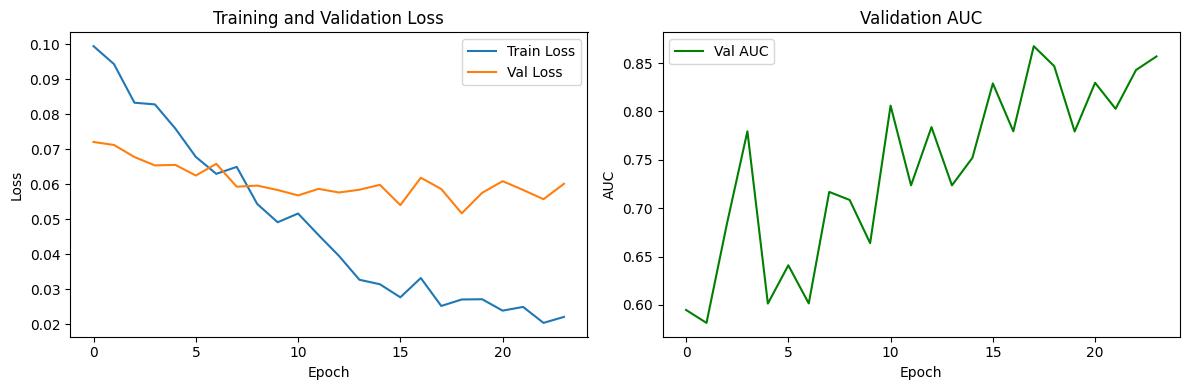

Training curves saved to ../models/training_curves.png


In [23]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

ax2.plot(val_aucs, label='Val AUC', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Validation AUC')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_path'], 'training_curves.png'), dpi=150)
plt.show()
print(f"Training curves saved to {CONFIG['model_path']}training_curves.png")


## 11. Model Loading and Verification


In [24]:
# Load best model
print("Loading best model...")
checkpoint = torch.load(os.path.join(CONFIG['model_path'], 'best_hgnn_model.pt'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1} with Val AUC: {checkpoint['val_auc']:.4f}")

# Verify model loaded correctly
print("\nVerifying model...")
model.eval()
print_gpu_memory("After model load")


Loading best model...
Loaded model from epoch 19 with Val AUC: 0.8469

Verifying model...
GPU Memory [After model load]: Allocated: 7.92 GB, Reserved: 7.93 GB


## 12. Full-Graph Inference


In [25]:
@torch.no_grad()
def batched_inference(model, g, ntype, batch_size, device):
    """Perform batched inference on full graph."""
    model.eval()
    num_nodes = g.num_nodes(ntype)
    all_preds = []
    
    # Create sampler for inference (larger neighborhood)
    sampler = NeighborSampler([15, 10])
    
    for start in tqdm(range(0, num_nodes, batch_size), desc=f"Inference on {ntype}"):
        end = min(start + batch_size, num_nodes)
        batch_nids = torch.arange(start, end)
        
        # Sample neighborhood
        loader = DataLoader(
            g,
            {ntype: batch_nids},
            sampler,
            batch_size=len(batch_nids),
            shuffle=False,
            num_workers=0
        )
        
        for input_nodes, output_nodes, blocks in loader:
            blocks = [b.to(device) for b in blocks]
            input_nodes = {k: v.to(device) for k, v in input_nodes.items()}
            
            # Forward pass
            h_dict = model.forward_blocks(blocks, input_nodes)
            
            if ntype == 'ingredient':
                pred = torch.sigmoid(model.predict_ingredients(h_dict)).cpu()
                all_preds.append(pred)
        
        # Clear cache periodically
        if (start // batch_size) % 5 == 0:
            clear_gpu_cache()
    
    return torch.cat(all_preds, dim=0)


# Run batched inference on all ingredients
print("Running batched full graph inference...")
print_gpu_memory("Before inference")

all_ingredient_preds = batched_inference(
    model, g, 'ingredient', 
    CONFIG['inference_batch_size'], device
)
print(f"Predictions shape: {all_ingredient_preds.shape}")
print_gpu_memory("After inference")


Running batched full graph inference...
GPU Memory [Before inference]: Allocated: 7.92 GB, Reserved: 7.93 GB


Inference on ingredient: 100%|██████████| 5/5 [00:12<00:00,  2.56s/it]

Predictions shape: torch.Size([225440, 5])
GPU Memory [After inference]: Allocated: 7.92 GB, Reserved: 9.03 GB


## 13. Evaluation and Metrics


In [26]:
def precision_at_k(y_true, y_pred, k):
    """
    Compute Precision@K for multi-label classification.
    For each sample, consider top-k predicted labels and compute precision.
    """
    n_samples = y_true.shape[0]
    precisions = []
    
    for i in range(n_samples):
        # Get top-k predicted indices
        top_k_idx = np.argsort(y_pred[i])[-k:]
        # Count how many are actually positive
        true_positives = y_true[i, top_k_idx].sum()
        precision = true_positives / k
        precisions.append(precision)
    
    return np.mean(precisions)


def precision_at_k_per_disease(y_true, y_pred, k, disease_idx):
    """Compute Precision@K for a specific disease column."""
    # Get top-k samples for this disease
    top_k_samples = np.argsort(y_pred[:, disease_idx])[-k:]
    # Count how many are actually positive
    true_positives = y_true[top_k_samples, disease_idx].sum()
    return true_positives / k


In [27]:
# Evaluate on test set
print("Evaluating on test set...")

test_preds = all_ingredient_preds[test_idx].numpy()
test_labels = ingredient_labels[test_idx].numpy()

# Calculate metrics for each disease
print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)

disease_metrics = {}
for i, disease in enumerate(CONFIG['target_diseases']):
    if test_labels[:, i].sum() > 0:
        auc = roc_auc_score(test_labels[:, i], test_preds[:, i])
        # Threshold at 0.5
        pred_binary = (test_preds[:, i] > 0.5).astype(int)
        f1 = f1_score(test_labels[:, i], pred_binary)
        
        # Precision@K for this disease
        p_at_5 = precision_at_k_per_disease(test_labels, test_preds, 5, i)
        p_at_10 = precision_at_k_per_disease(test_labels, test_preds, 10, i)
        
        disease_metrics[disease] = {
            'auc': auc, 'f1': f1, 'p@5': p_at_5, 'p@10': p_at_10
        }
        print(f"  {disease.upper():25} | AUC: {auc:.4f} | F1: {f1:.4f} | P@5: {p_at_5:.4f} | P@10: {p_at_10:.4f}")

# Overall metrics
pred_binary = (test_preds > 0.5).astype(int)
micro_f1 = f1_score(test_labels, pred_binary, average='micro')
macro_f1 = f1_score(test_labels, pred_binary, average='macro')

# Overall Precision@K
overall_p5 = precision_at_k(test_labels, test_preds, 5)
overall_p10 = precision_at_k(test_labels, test_preds, 10)

print("\n" + "-"*60)
print(f"  MICRO F1: {micro_f1:.4f}")
print(f"  MACRO F1: {macro_f1:.4f}")
print(f"  OVERALL P@5: {overall_p5:.4f}")
print(f"  OVERALL P@10: {overall_p10:.4f}")


Evaluating on test set...

TEST SET RESULTS
  DIABETES                  | AUC: 1.0000 | F1: 1.0000 | P@5: 1.0000 | P@10: 1.0000
  OBESITY                   | AUC: 0.9375 | F1: 0.9846 | P@5: 1.0000 | P@10: 1.0000
  HYPERTENSION              | AUC: 1.0000 | F1: 1.0000 | P@5: 1.0000 | P@10: 1.0000
  CANCER                    | AUC: 0.3939 | F1: 0.1667 | P@5: 1.0000 | P@10: 1.0000
  CARDIOVASCULAR DISEASE    | AUC: 0.8759 | F1: 0.9355 | P@5: 1.0000 | P@10: 1.0000

------------------------------------------------------------
  MICRO F1: 0.8814
  MACRO F1: 0.8174
  OVERALL P@5: 0.9412
  OVERALL P@10: 0.4706


In [28]:
# Show high-risk ingredient predictions
print("\n" + "="*60)
print("TOP 10 HIGH-RISK INGREDIENTS PER DISEASE")
print("="*60)

for i, disease in enumerate(CONFIG['target_diseases']):
    print(f"\n{disease.upper()}:")
    disease_preds = all_ingredient_preds[:, i].numpy()
    top_indices = disease_preds.argsort()[-10:][::-1]
    
    for rank, idx in enumerate(top_indices, 1):
        ing_name = id2ingredient[idx]
        prob = disease_preds[idx]
        print(f"  {rank:2}. {ing_name[:40]:40} (risk: {prob:.3f})")



TOP 10 HIGH-RISK INGREDIENTS PER DISEASE

DIABETES:
   1. carrot                                   (risk: 0.990)
   2. buckwheat                                (risk: 0.990)
   3. tuna                                     (risk: 0.990)
   4. SUCED CARROTS                            (risk: 0.989)
   5. saturated fatty acids                    (risk: 0.989)
   6. pantothenic acid                         (risk: 0.989)
   7. copper                                   (risk: 0.989)
   8. glucose                                  (risk: 0.989)
   9. SODIUM TRIPOLYPHOSPHATE*                 (risk: 0.988)
  10. dark chocolate                           (risk: 0.987)

OBESITY:
   1. protein                                  (risk: 0.984)
   2. cranberry                                (risk: 0.980)
   3. aspartame                                (risk: 0.979)
   4. alpha-linolenic acid                     (risk: 0.979)
   5. broccoli                                 (risk: 0.978)
   6. omega-6 fatty ac

## 14. Food Risk Prediction Examples


In [29]:
def predict_food_risk(food_id, ingredient_preds, g, food2id, id2ingredient):
    """Predict disease risk for a food based on its ingredients."""
    # Get ingredients for this food
    food_idx = food2id.get(food_id)
    if food_idx is None:
        return None
    
    # Get ingredient neighbors
    subg = g['food', 'contains', 'ingredient']
    _, ingredient_indices = subg.out_edges(food_idx)
    ingredient_indices = ingredient_indices.numpy()
    
    if len(ingredient_indices) == 0:
        return None
    
    # Aggregate ingredient risks (max pooling)
    ingredient_risks = ingredient_preds[ingredient_indices]
    food_risk = ingredient_risks.max(dim=0).values.numpy()
    
    return food_risk, [id2ingredient[i] for i in ingredient_indices]


# Example predictions
print("\n" + "="*60)
print("SAMPLE FOOD RISK PREDICTIONS")
print("="*60)

# Get a sample of foods
sample_foods = list(food2id.keys())[:5]

for food_id in sample_foods:
    result = predict_food_risk(food_id, all_ingredient_preds, g, food2id, id2ingredient)
    if result:
        risks, ingredients = result
        food_name = id2food.get(food2id[food_id], food_id)
        print(f"\nFood: {food_name[:50]}")
        print(f"Ingredients ({len(ingredients)}): {', '.join(ingredients[:5])}...")
        print("Disease Risks:")
        for i, disease in enumerate(CONFIG['target_diseases']):
            print(f"  - {disease}: {risks[i]:.3f}")



SAMPLE FOOD RISK PREDICTIONS

Food: food_1105904
Ingredients (1): VEGETABLE OIL...
Disease Risks:
  - diabetes: 0.880
  - obesity: 0.511
  - hypertension: 0.552
  - cancer: 0.465
  - cardiovascular disease: 0.749

Food: food_1105905
Ingredients (1): BEEF STOCK...
Disease Risks:
  - diabetes: 0.931
  - obesity: 0.832
  - hypertension: 0.914
  - cancer: 0.440
  - cardiovascular disease: 0.870

Food: food_1105906
Ingredients (6): CLAM STOCK, POTATOES, CLAMS, CREAM, VEGETABLE OIL...
Disease Risks:
  - diabetes: 0.880
  - obesity: 0.703
  - hypertension: 0.772
  - cancer: 0.652
  - cardiovascular disease: 0.763

Food: food_1105907
Ingredients (7): WATER, CREAM, BROCCOLI, CELERY, VEGETABLE OIL...
Disease Risks:
  - diabetes: 0.959
  - obesity: 0.888
  - hypertension: 0.919
  - cancer: 0.652
  - cardiovascular disease: 0.914

Food: food_1105908
Ingredients (1): CHICKEN STOCK...
Disease Risks:
  - diabetes: 0.908
  - obesity: 0.813
  - hypertension: 0.909
  - cancer: 0.606
  - cardiovascular 

## 15. Save Outputs


In [30]:
# Save predictions
print("\nSaving predictions...")

# Save ingredient predictions
ingredient_pred_df = pd.DataFrame(
    all_ingredient_preds.numpy(),
    columns=[f'{d}_risk' for d in CONFIG['target_diseases']]
)
ingredient_pred_df['ingredient'] = [id2ingredient[i] for i in range(len(ingredient_pred_df))]
ingredient_pred_df = ingredient_pred_df[['ingredient'] + [f'{d}_risk' for d in CONFIG['target_diseases']]]
ingredient_pred_df.to_csv(os.path.join(CONFIG['model_path'], 'ingredient_risk_predictions.csv'), index=False)

print(f"Saved {len(ingredient_pred_df)} ingredient predictions")
ingredient_pred_df.head(10)



Saving predictions...
Saved 225440 ingredient predictions


,ingredient,diabetes_risk,obesity_risk,hypertension_risk,cancer_risk,cardiovascular disease_risk
0,TANGY CHIPOTLE SAUCE,0.700576,0.680452,0.139485,0.410091,0.634222
1,RED MARASCHINO CHERRIES,0.454736,0.436938,0.579564,0.572626,0.728553
2,DEHYDRATED RED BELL PEPPER),0.790574,0.682114,0.626193,0.468933,0.757938
3,BACON BASE,0.878756,0.753918,0.838016,0.358697,0.899820
4,BBQ COATED PEANUTS,0.722019,0.736715,0.730790,0.352214,0.778813
5,FRTA CHEESE,0.579879,0.294611,0.306458,0.538435,0.470362
6,CANNED JALAPENO PEPPERS,0.296884,0.471279,0.478877,0.425830,0.610114
7,YEAST FLAKES*,0.845556,0.709650,0.742602,0.476368,0.687706
8,WHITE CHOCOLATY CHUNKS,0.922842,0.851500,0.859661,0.281712,0.827701
9,PURE FOOD GLAZE,0.701212,0.598319,0.349016,0.445455,0.612805


In [31]:
# Summary
print("\n" + "="*60)
print("STEP 7: GNN RISK PREDICTION - COMPLETE")
print("="*60)
print(f"\n✅ Model trained with {checkpoint['epoch']+1} epochs")
print(f"✅ Best Validation AUC: {checkpoint['val_auc']:.4f}")
print(f"✅ Predictions saved for {len(all_ingredient_preds):,} ingredients")
print(f"\nOutput files:")
print(f"  - {CONFIG['model_path']}best_hgnn_model.pt")
print(f"  - {CONFIG['model_path']}ingredient_risk_predictions.csv")
print(f"  - {CONFIG['model_path']}training_curves.png")

print_gpu_memory("Final")



STEP 7: GNN RISK PREDICTION - COMPLETE

✅ Model trained with 19 epochs
✅ Best Validation AUC: 0.8469
✅ Predictions saved for 225,440 ingredients

Output files:
  - ../models/best_hgnn_model.pt
  - ../models/ingredient_risk_predictions.csv
  - ../models/training_curves.png
GPU Memory [Final]: Allocated: 7.92 GB, Reserved: 9.03 GB
